# 🔋 Complete Hybrid ECM-LSTM Implementation
## SOC, SOH, and RUL Prediction

This notebook demonstrates the complete hybrid approach combining:
- **Physics-based ECM** (Equivalent Circuit Model)
- **Data-driven LSTM** (Long Short-Term Memory)

### 📊 What We'll Predict:
1. **SOC** (State of Charge) - Battery charge level (0-100%)
2. **SOH** (State of Health) - Battery health degradation (0-100%)
3. **RUL** (Remaining Useful Life) - Cycles until end-of-life

### 🎯 Why Hybrid?
| Approach | Pros | Cons |
|----------|------|------|
| **ECM Only** | ✅ Interpretable<br>✅ Fast | ❌ Limited accuracy |
| **LSTM Only** | ✅ High accuracy | ❌ Black box<br>❌ Needs lots of data |
| **Hybrid** | ✅ Best accuracy<br>✅ Interpretable<br>✅ Less data needed | ⚠️ More complex |

In [1]:
# Import libraries
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import hybrid models
from hybrid_soc import HybridECMLSTM_SOC, run_hybrid_soc_analysis
from hybrid_soh import HybridECMLSTM_SOH, run_hybrid_soh_analysis
from hybrid_rul import HybridECMLSTM_RUL, run_hybrid_rul_analysis

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 1️⃣ SOC Prediction (State of Charge)

### What is SOC?
SOC represents the current charge level of the battery (like a fuel gauge).
- **Range**: 0% (empty) to 100% (full)
- **Use Case**: Real-time battery monitoring, range estimation

### Hybrid Approach:
```
Raw Data → ECM → [R0, R1, C1, τ1]
                        ↓
         [V, I, T] + [ECM Params]
                        ↓
              Bidirectional LSTM
                        ↓
                  SOC Prediction
```

🔋 Starting SOC Prediction...

Hybrid ECM-LSTM SOC Analysis - Battery B0005
Step 1: Extracting ECM parameters for SOC...
Loading battery B0005...
Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.0049015892074626, 24.330033885570543, -0.0006, 0.0, 0.0]
Loaded 168 discharge cycles

Extracting RC parameters over lifetime...
Analyzing every 5 cycles...
Processing cycle 166/168...
Completed! Analyzed 34 cycles.
✓ Extracted ECM parameters for 34 cycles

Step 2: Preparing SOC sequences with hybrid features...
Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.0049015892074626, 24.330033885570543, -0.0006, 0.0, 0.0]
✓ Created 154 sequences
  - Sequence shape: (154, 100, 9)
  - Features: 5 raw + 4 ECM = 9 total
  - Target shape: (154, 100)

Step 3: Building hybrid Bidirectional LSTM model for SOC...
✓ Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 100, 256)            │         141,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 100, 128)            │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 32)             │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100, 16)             │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100, 1)              │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 326,817 (1.25 MB)

 Trainable params: 326,817 (1.25 MB)

...


Epoch 98: finished saving model to hybrid/best_hybrid_soc_model.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - loss: 0.0037 - mae: 0.0467 - mse: 0.0037 - val_loss: 0.0016 - val_mae: 0.0317 - val_mse: 0.0016 - learning_rate: 2.5000e-04
Epoch 99/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - loss: 0.0037 - mae: 0.0467 - mse: 0.0037
Epoch 99: val_loss did not improve from 0.00155
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 676ms/step - loss: 0.0036 - mae: 0.0467 - mse: 0.0036 - val_loss: 0.0016 - val_mae: 0.0314 - val_mse: 0.0016 - learning_rate: 2.5000e-04
Epoch 100/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.0038 - mae: 0.0470 - mse: 0.0038
Epoch 100: val_loss improved from 0.00155 to 0.00155, saving model to hybrid/best_hybrid_soc_model.h5



Epoch 100: finished saving model to hybrid/best_hybrid_soc_model.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step - loss: 0.0037 - mae: 0.0466 - mse: 0.0037 - val_loss: 0.0016 - val_mae: 0.0309 - val_mse: 0.0016 - learning_rate: 2.5000e-04
Epoch 101/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - loss: 0.0039 - mae: 0.0484 - mse: 0.0039
Epoch 101: val_loss did not improve from 0.00155
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 665ms/step - loss: 0.0037 - mae: 0.0473 - mse: 0.0037 - val_loss: 0.0016 - val_mae: 0.0324 - val_mse: 0.0016 - learning_rate: 2.5000e-04
Epoch 102/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - loss: 0.0034 - mae: 0.0449 - mse: 0.0034
Epoch 102: val_loss did not improve from 0.00155
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 908ms/step - loss: 0.0035 - mae: 0.0458 - mse: 0.0035 - val_loss: 0.0016 - val_mae: 0.0317 - val_mse: 0.0016 - learning_rate: 2.5000e-04
Epoch 103/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - loss: 0.0035 - mae: 0.0457 - mse: 0.0035
Epoch 103: val_loss improved from 0.00155 to 0.001


Epoch 103: finished saving model to hybrid/best_hybrid_soc_model.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0035 - mae: 0.0460 - mse: 0.0035 - val_loss: 0.0015 - val_mae: 0.0314 - val_mse: 0.0015 - learning_rate: 2.5000e-04
Epoch 104/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - loss: 0.0037 - mae: 0.0468 - mse: 0.0037
Epoch 104: val_loss improved from 0.00152 to 0.00144, saving model to hybrid/best_hybrid_soc_model.h5



Epoch 104: finished saving model to hybrid/best_hybrid_soc_model.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 928ms/step - loss: 0.0038 - mae: 0.0475 - mse: 0.0038 - val_loss: 0.0014 - val_mae: 0.0296 - val_mse: 0.0014 - learning_rate: 2.5000e-04
Epoch 105/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - loss: 0.0035 - mae: 0.0449 - mse: 0.0035
Epoch 105: val_loss did not improve from 0.00144
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 894ms/step - loss: 0.0037 - mae: 0.0471 - mse: 0.0037 - val_loss: 0.0016 - val_mae: 0.0311 - val_mse: 0.0016 - learning_rate: 2.5000e-04
Epoch 106/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - loss: 0.0037 - mae: 0.0467 - mse: 0.0037
Epoch 106: val_loss did not improve from 0.00144
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 943ms/step - loss: 0.0037 - mae: 0.0467 - mse: 0.0037 - val_loss: 0.0017 - val_mae: 0.0353 - val_mse: 0.0017 - learning_rate: 2.5000e-04
Epoch 107/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - loss: 0.0038 - mae: 0.0476 - mse: 0.0038
Epoch 107: val_loss improved from 0.00144 to 0.001


Epoch 107: finished saving model to hybrid/best_hybrid_soc_model.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 700ms/step - loss: 0.0037 - mae: 0.0468 - mse: 0.0037 - val_loss: 0.0014 - val_mae: 0.0284 - val_mse: 0.0014 - learning_rate: 2.5000e-04
Epoch 108/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - loss: 0.0038 - mae: 0.0482 - mse: 0.0038
Epoch 108: val_loss did not improve from 0.00137
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 614ms/step - loss: 0.0038 - mae: 0.0476 - mse: 0.0038 - val_loss: 0.0014 - val_mae: 0.0290 - val_mse: 0.0014 - learning_rate: 2.5000e-04
Epoch 109/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - loss: 0.0038 - mae: 0.0472 - mse: 0.0038
Epoch 109: val_loss did not improve from 0.00137
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 583ms/step - loss: 0.0036 - mae: 0.0463 - mse: 0.0036 - val_loss: 0.0017 - val_mae: 0.0346 - val_mse: 0.0017 - learning_rate: 2.5000e-04
Epoch 110/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.0037 - mae: 0.0461 - mse: 0.0037
Epoch 110: val_loss did not improve from 0.00137
4

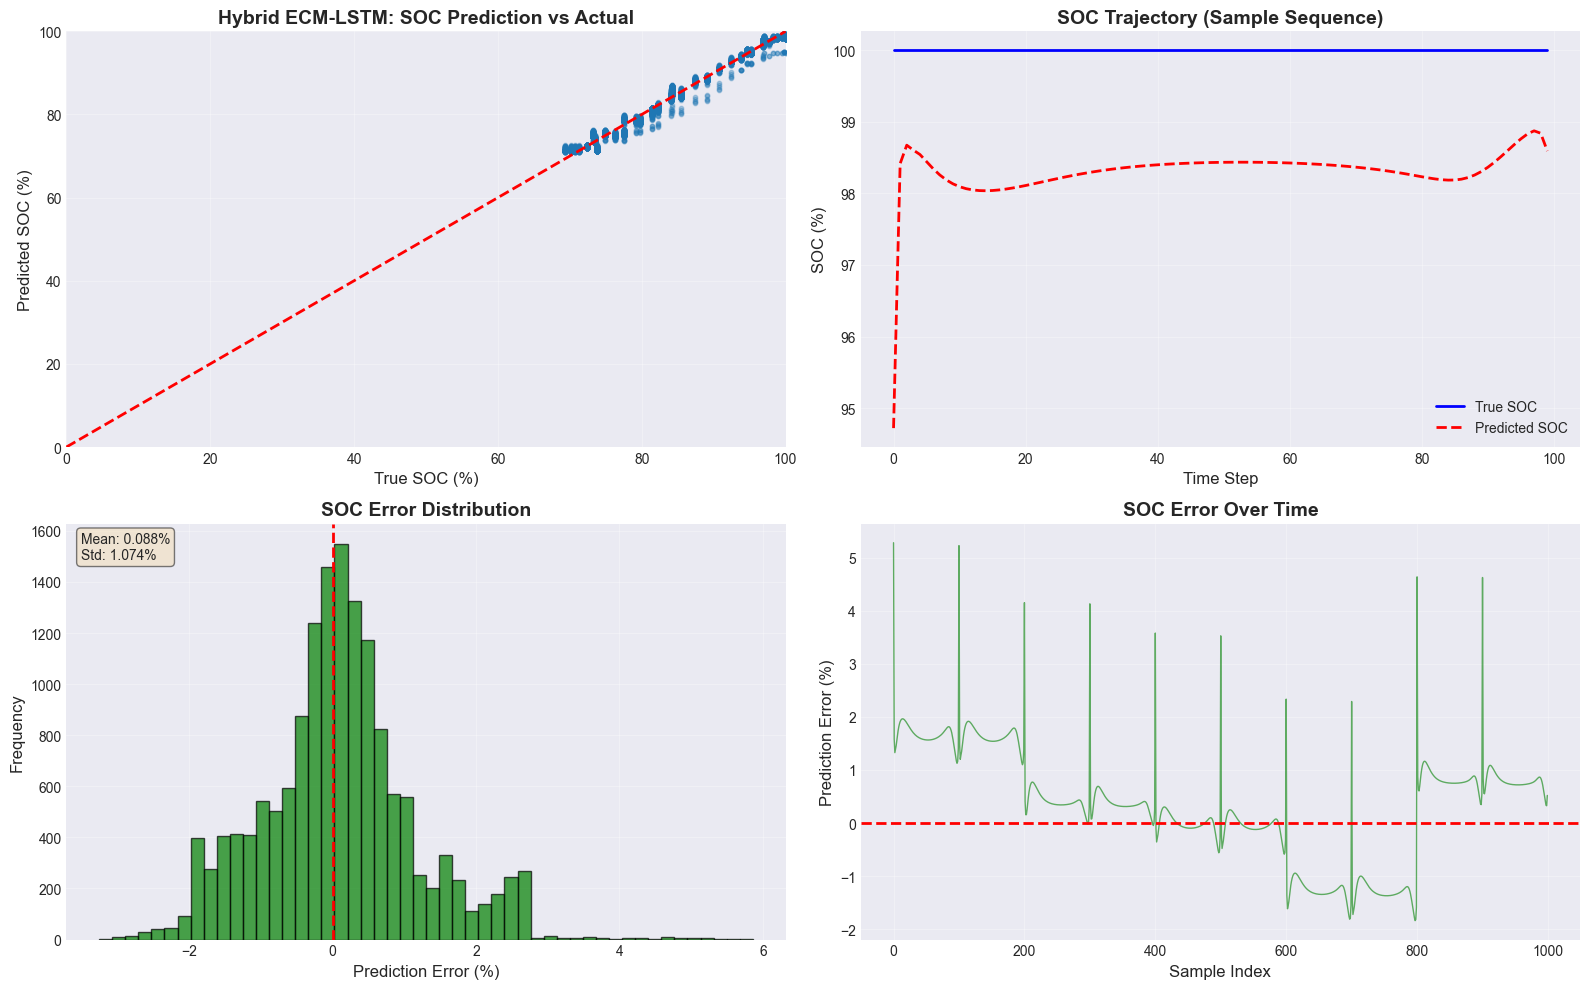

In [2]:
# Run complete SOC analysis
print("🔋 Starting SOC Prediction...\n")
hybrid_soc, metrics_soc = run_hybrid_soc_analysis('B0005')

print("\n" + "="*60)
print("SOC Prediction Results:")
print("="*60)
print(f"RMSE:  {metrics_soc['RMSE']:.4f}%")
print(f"MAE:   {metrics_soc['MAE']:.4f}%")
print(f"R²:    {metrics_soc['R2']:.6f}")
print(f"MAPE:  {metrics_soc['MAPE']:.2f}%")
print("="*60)

---
## 2️⃣ SOH Prediction (State of Health)

### What is SOH?
SOH represents the overall health/capacity of the battery compared to when it was new.
- **Range**: 0% (dead) to 100% (new)
- **Use Case**: Battery warranty, replacement planning

### Hybrid Approach:
```
Raw Data → ECM → [R0, R1, C1, τ1]
                        ↓
         [V, I, T] + [ECM Params]
                        ↓
                   LSTM Layers
                        ↓
                  SOH Prediction
```

🔋 Starting SOH Prediction...

Hybrid ECM-LSTM SOH Analysis - Battery B0005
Step 1: Extracting ECM parameters for SOH...
Loading battery B0005...
Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.0049015892074626, 24.330033885570543, -0.0006, 0.0, 0.0]
Loaded 168 discharge cycles

Extracting RC parameters over lifetime...
Analyzing every 5 cycles...
Processing cycle 166/168...
Completed! Analyzed 34 cycles.
✓ Extracted ECM parameters for 34 cycles

Step 2: Preparing hybrid features for SOH...
Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.0049015892074626, 24.330033885570543, -0.0006, 0.0, 0.0]
✓ Created 34 sequences
  - Sequence shape: (34, 50, 9)
  - Features: 5 raw + 4 ECM = 9 total
  - Target shape: (34,)

Step 3: Building hybrid LSTM model for SOH...
✓ Model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 50, 128)             │          70,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,689 (479.25 KB)

 Trainable params: 122,689 (479.25 KB)

...


Epoch 9: finished saving model to hybrid/best_hybrid_soh_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step - loss: 0.0884 - mae: 0.2290 - mse: 0.0884 - val_loss: 0.0089 - val_mae: 0.0843 - val_mse: 0.0089 - learning_rate: 0.0010
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.0550 - mae: 0.1799 - mse: 0.0550
Epoch 10: val_loss did not improve from 0.00889
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step - loss: 0.0603 - mae: 0.1954 - mse: 0.0603 - val_loss: 0.0111 - val_mae: 0.0902 - val_mse: 0.0111 - learning_rate: 0.0010
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0487 - mae: 0.1935 - mse: 0.0487 
Epoch 11: val_loss improved from 0.00889 to 0.00571, saving model to hybrid/best_hybrid_soh_model.h5



Epoch 11: finished saving model to hybrid/best_hybrid_soh_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - loss: 0.0501 - mae: 0.1942 - mse: 0.0501 - val_loss: 0.0057 - val_mae: 0.0662 - val_mse: 0.0057 - learning_rate: 0.0010
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0345 - mae: 0.1452 - mse: 0.0345
Epoch 12: val_loss did not improve from 0.00571
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - loss: 0.0407 - mae: 0.1625 - mse: 0.0407 - val_loss: 0.0115 - val_mae: 0.0835 - val_mse: 0.0115 - learning_rate: 0.0010
Epoch 13/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.0412 - mae: 0.1697 - mse: 0.0412
Epoch 13: val_loss did not improve from 0.00571
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 0.0300 - mae: 0.1401 - mse: 0.0300 - val_loss: 0.0363 - val_mae: 0.1645 - val_mse: 0.0363 - learning_rate: 0.0010
Epoch 14/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0384 - mae: 0.1652 - mse: 0.0384
Epoch 14: val_loss did not improve from 0.00571
2/2 ━━━━━━━━━━━━━━━━


Epoch 22: finished saving model to hybrid/best_hybrid_soh_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 0.0281 - mae: 0.1275 - mse: 0.0281 - val_loss: 0.0056 - val_mae: 0.0598 - val_mse: 0.0056 - learning_rate: 5.0000e-04
Epoch 23/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0635 - mae: 0.1848 - mse: 0.0635
Epoch 23: val_loss did not improve from 0.00562
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.0509 - mae: 0.1643 - mse: 0.0509 - val_loss: 0.0064 - val_mae: 0.0687 - val_mse: 0.0064 - learning_rate: 5.0000e-04
Epoch 24/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0339 - mae: 0.1410 - mse: 0.0339
Epoch 24: val_loss did not improve from 0.00562
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.0290 - mae: 0.1371 - mse: 0.0290 - val_loss: 0.0104 - val_mae: 0.0816 - val_mse: 0.0104 - learning_rate: 5.0000e-04
Epoch 25/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0301 - mae: 0.1247 - mse: 0.0301 
Epoch 25: val_loss did not improve from 0.00562
2/2 ━━━━━━

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/stepWARNING:tensorflow:6 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000270201453A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 485ms/step

Model                RMSE         MAE          R²          
------------------------------------------------------------
Baseline LSTM        5.3612       4.0513       0.731412    
Hybrid ECM-LSTM      2.5935       2.0249       0.937144    
------------------------------------------------------------
Improvement          +51.62%      +50.02%      +28.13%

✅ Hybrid SOH analysis complete!
Results saved to: hybrid/results/B0005_hybrid_soh_results.png

SOH Prediction Results:
RMSE:  2.5935%
MAE:   2.0249%
R²:    0.937144
MAPE:  2.48%

📊 Improvement over Baseline LSTM:
  RMSE: +51.62%
  MAE:  +50.02%
  R²:   +28.13%


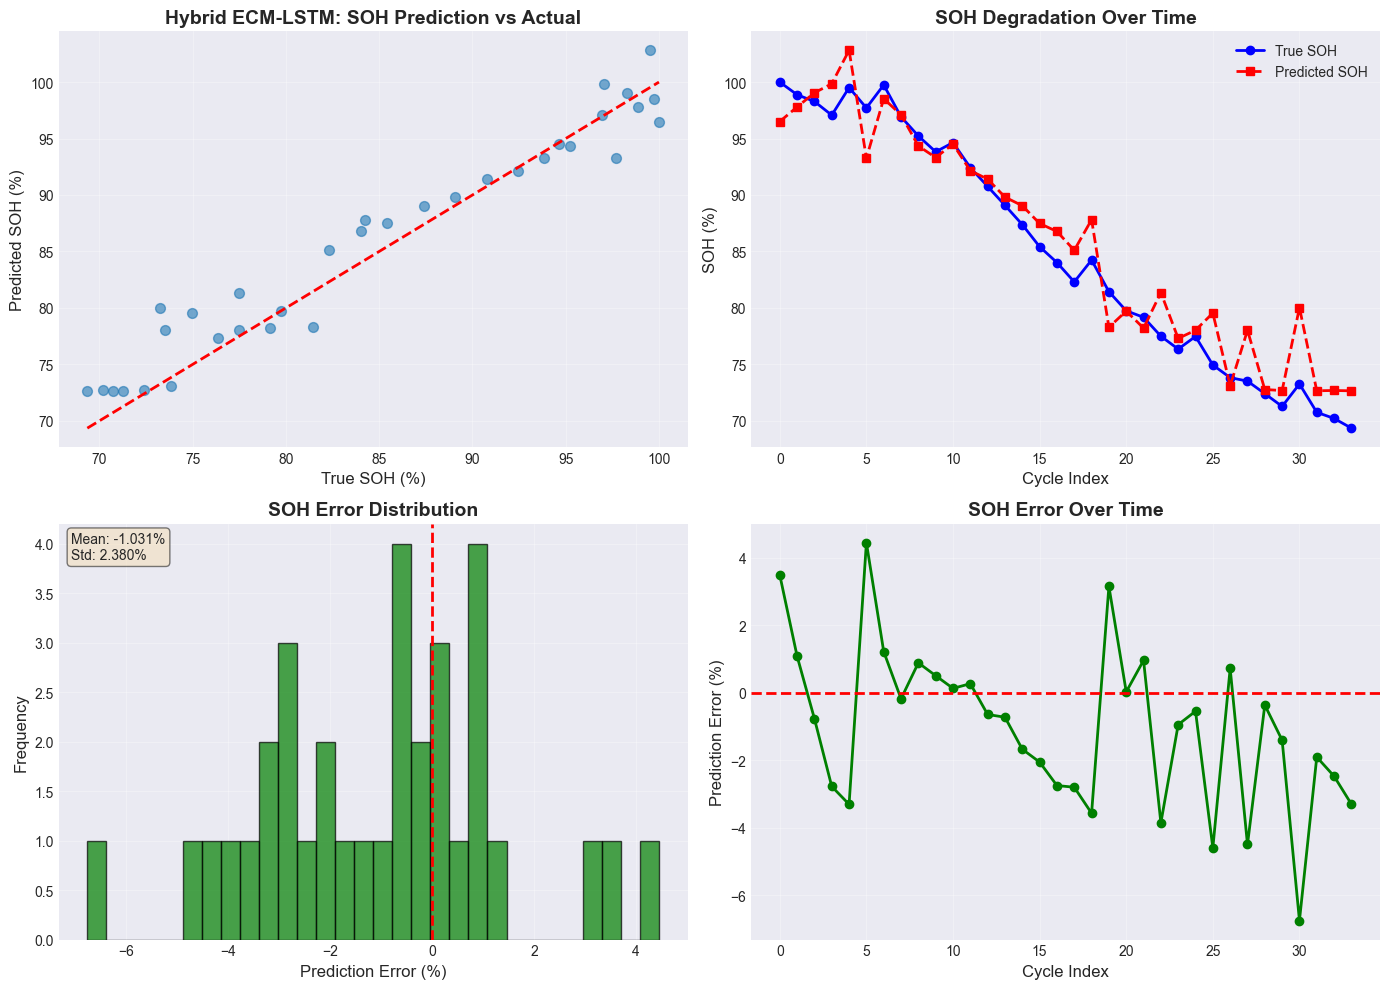

In [3]:
# Run complete SOH analysis
print("🔋 Starting SOH Prediction...\n")
hybrid_soh, metrics_soh, comparison_soh = run_hybrid_soh_analysis('B0005')

print("\n" + "="*60)
print("SOH Prediction Results:")
print("="*60)
print(f"RMSE:  {metrics_soh['RMSE']:.4f}%")
print(f"MAE:   {metrics_soh['MAE']:.4f}%")
print(f"R²:    {metrics_soh['R2']:.6f}")
print(f"MAPE:  {metrics_soh['MAPE']:.2f}%")
print("="*60)

print("\n📊 Improvement over Baseline LSTM:")
print(f"  RMSE: {comparison_soh['improvement']['RMSE']:+.2f}%")
print(f"  MAE:  {comparison_soh['improvement']['MAE']:+.2f}%")
print(f"  R²:   {comparison_soh['improvement']['R2']:+.2f}%")

---
## 3️⃣ RUL Prediction (Remaining Useful Life)

### What is RUL?
RUL predicts how many charge cycles remain before the battery reaches end-of-life (EOL).
- **EOL Criteria**: SOH < 80% (capacity drops below 80% of original)
- **Use Case**: Maintenance scheduling, battery replacement planning

### Hybrid Approach:
```
Raw Data → ECM → [R0, R1, C1, τ1]
                        ↓
    [V, I, T] + [Degradation] + [ECM Params]
                        ↓
              Bidirectional LSTM
                        ↓
              RUL Prediction (cycles)
```

🔋 Starting RUL Prediction...

Hybrid ECM-LSTM RUL Analysis - Battery B0005
Step 1: Extracting ECM parameters for RUL...
Loading battery B0005...
Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.0049015892074626, 24.330033885570543, -0.0006, 0.0, 0.0]
Loaded 168 discharge cycles

Extracting RC parameters over lifetime...
Analyzing every 5 cycles...
Processing cycle 166/168...
Completed! Analyzed 34 cycles.
✓ Extracted ECM parameters for 34 cycles

Step 2: Preparing RUL features with hybrid approach...
Total data in dataset:  168
[1, 24.0, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.0049015892074626, 24.330033885570543, -0.0006, 0.0, 0.0]
✓ EOL cycle identified: 101 (SOH < 80.0%)
✓ Created 20 sequences
  - Sequence shape: (20, 30, 13)
  - Features: 5 raw + 4 degradation + 4 ECM = 13 total
  - Target shape: (20,)
  - RUL range: 5 to 100 cycles

Step 3: Building hybrid Bidirec

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional)      │ (None, 30, 256)             │         145,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 30, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 320,641 (1.22 MB)

 Trainable params: 320,641 (1.22 MB)

...


Epoch 3: finished saving model to hybrid/best_hybrid_rul_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - loss: 0.0896 - mae: 0.2409 - mse: 0.0896 - val_loss: 0.0101 - val_mae: 0.0987 - val_mse: 0.0101 - learning_rate: 0.0010
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - loss: 0.0909 - mae: 0.2438 - mse: 0.0909
Epoch 4: val_loss improved from 0.01013 to 0.00932, saving model to hybrid/best_hybrid_rul_model.h5



Epoch 4: finished saving model to hybrid/best_hybrid_rul_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step - loss: 0.0909 - mae: 0.2438 - mse: 0.0909 - val_loss: 0.0093 - val_mae: 0.0784 - val_mse: 0.0093 - learning_rate: 0.0010
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0657 - mae: 0.2310 - mse: 0.0657
Epoch 5: val_loss did not improve from 0.00932
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - loss: 0.0657 - mae: 0.2310 - mse: 0.0657 - val_loss: 0.0546 - val_mae: 0.2060 - val_mse: 0.0546 - learning_rate: 0.0010
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0794 - mae: 0.2296 - mse: 0.0794
Epoch 6: val_loss did not improve from 0.00932
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 0.0794 - mae: 0.2296 - mse: 0.0794 - val_loss: 0.1043 - val_mae: 0.2801 - val_mse: 0.1043 - learning_rate: 0.0010
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0347 - mae: 0.1520 - mse: 0.0347
Epoch 7: val_loss did not improve from 0.00932
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2


Epoch 12: finished saving model to hybrid/best_hybrid_rul_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step - loss: 0.0218 - mae: 0.1039 - mse: 0.0218 - val_loss: 0.0077 - val_mae: 0.0758 - val_mse: 0.0077 - learning_rate: 0.0010
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - loss: 0.0231 - mae: 0.1288 - mse: 0.0231
Epoch 13: val_loss improved from 0.00772 to 0.00611, saving model to hybrid/best_hybrid_rul_model.h5



Epoch 13: finished saving model to hybrid/best_hybrid_rul_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0231 - mae: 0.1288 - mse: 0.0231 - val_loss: 0.0061 - val_mae: 0.0673 - val_mse: 0.0061 - learning_rate: 0.0010
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - loss: 0.0449 - mae: 0.1822 - mse: 0.0449
Epoch 14: val_loss did not improve from 0.00611
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step - loss: 0.0449 - mae: 0.1822 - mse: 0.0449 - val_loss: 0.0093 - val_mae: 0.0839 - val_mse: 0.0093 - learning_rate: 0.0010
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 0.0451 - mae: 0.1741 - mse: 0.0451
Epoch 15: val_loss did not improve from 0.00611
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step - loss: 0.0451 - mae: 0.1741 - mse: 0.0451 - val_loss: 0.0122 - val_mae: 0.0969 - val_mse: 0.0122 - learning_rate: 0.0010
Epoch 16/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - loss: 0.0196 - mae: 0.1212 - mse: 0.0196
Epoch 16: val_loss did not improve from 0.00611
1/1 ━━━━━━━━━━━━━━━━━━━


Epoch 23: finished saving model to hybrid/best_hybrid_rul_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 985ms/step - loss: 0.0155 - mae: 0.1009 - mse: 0.0155 - val_loss: 0.0050 - val_mae: 0.0561 - val_mse: 0.0050 - learning_rate: 0.0010
Epoch 24/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - loss: 0.0424 - mae: 0.1428 - mse: 0.0424
Epoch 24: val_loss did not improve from 0.00503
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step - loss: 0.0424 - mae: 0.1428 - mse: 0.0424 - val_loss: 0.0061 - val_mae: 0.0614 - val_mse: 0.0061 - learning_rate: 0.0010
Epoch 25/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 0.0137 - mae: 0.0963 - mse: 0.0137
Epoch 25: val_loss did not improve from 0.00503
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step - loss: 0.0137 - mae: 0.0963 - mse: 0.0137 - val_loss: 0.0088 - val_mae: 0.0724 - val_mse: 0.0088 - learning_rate: 0.0010
Epoch 26/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - loss: 0.0110 - mae: 0.0802 - mse: 0.0110
Epoch 26: val_loss did not improve from 0.00503
1/1 ━━━━━━━━━━━━━━━━

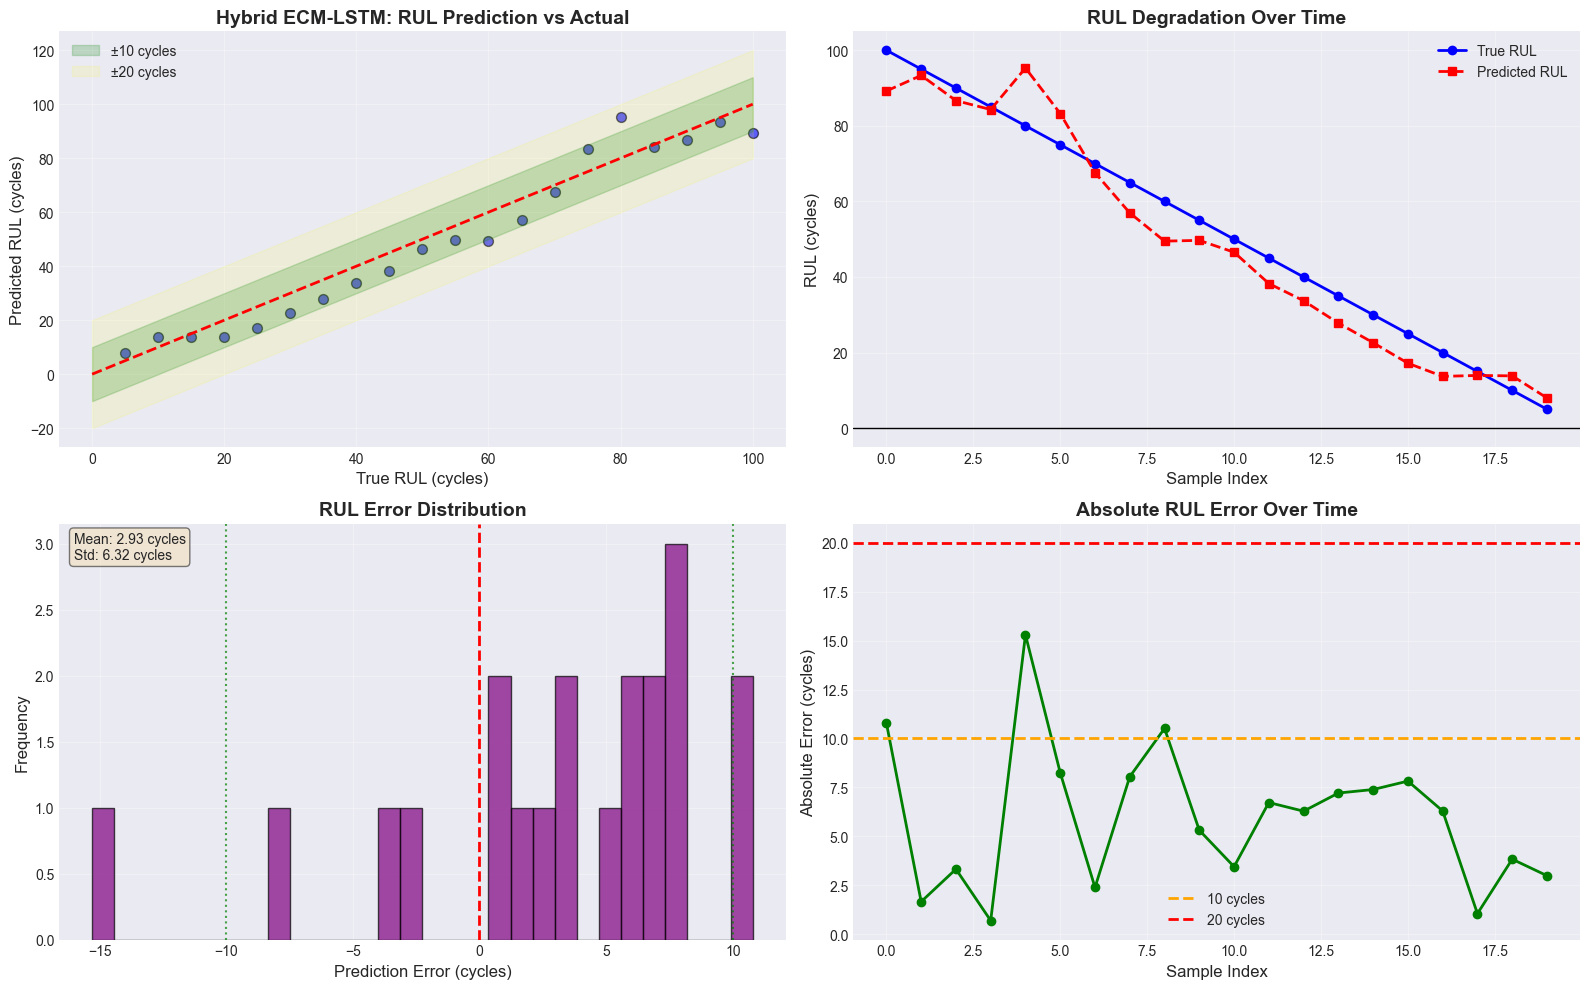

In [4]:
# Run complete RUL analysis
print("🔋 Starting RUL Prediction...\n")
hybrid_rul, metrics_rul, comparison_rul = run_hybrid_rul_analysis('B0005')

print("\n" + "="*60)
print("RUL Prediction Results:")
print("="*60)
print(f"RMSE:              {metrics_rul['RMSE']:.2f} cycles")
print(f"MAE:               {metrics_rul['MAE']:.2f} cycles")
print(f"R²:                {metrics_rul['R2']:.6f}")
print(f"MAPE:              {metrics_rul['MAPE']:.2f}%")
print(f"Within ±10 cycles: {metrics_rul['Within_10_Cycles']:.1f}%")
print(f"Within ±20 cycles: {metrics_rul['Within_20_Cycles']:.1f}%")
print("="*60)

print("\n📊 Improvement over Baseline LSTM:")
print(f"  RMSE: {comparison_rul['improvement']['RMSE']:+.2f}%")
print(f"  MAE:  {comparison_rul['improvement']['MAE']:+.2f}%")
print(f"  R²:   {comparison_rul['improvement']['R2']:+.2f}%")

---
## 📊 Summary Comparison

Let's compare all three predictions:

In [5]:
# Create summary comparison
summary_df = pd.DataFrame({
    'Metric': ['SOC', 'SOH', 'RUL'],
    'RMSE': [
        f"{metrics_soc['RMSE']:.4f}%",
        f"{metrics_soh['RMSE']:.4f}%",
        f"{metrics_rul['RMSE']:.2f} cycles"
    ],
    'MAE': [
        f"{metrics_soc['MAE']:.4f}%",
        f"{metrics_soh['MAE']:.4f}%",
        f"{metrics_rul['MAE']:.2f} cycles"
    ],
    'R²': [
        f"{metrics_soc['R2']:.6f}",
        f"{metrics_soh['R2']:.6f}",
        f"{metrics_rul['R2']:.6f}"
    ],
    'MAPE': [
        f"{metrics_soc['MAPE']:.2f}%",
        f"{metrics_soh['MAPE']:.2f}%",
        f"{metrics_rul['MAPE']:.2f}%"
    ]
})

print("\n" + "="*80)
print("HYBRID ECM-LSTM PERFORMANCE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


HYBRID ECM-LSTM PERFORMANCE SUMMARY
Metric        RMSE         MAE       R²   MAPE
   SOC     1.0773%     0.7964% 0.987885  0.99%
   SOH     2.5935%     2.0249% 0.937144  2.48%
   RUL 6.97 cycles 5.97 cycles 0.941591 17.05%


---
## 🎨 Visualize All Results Together

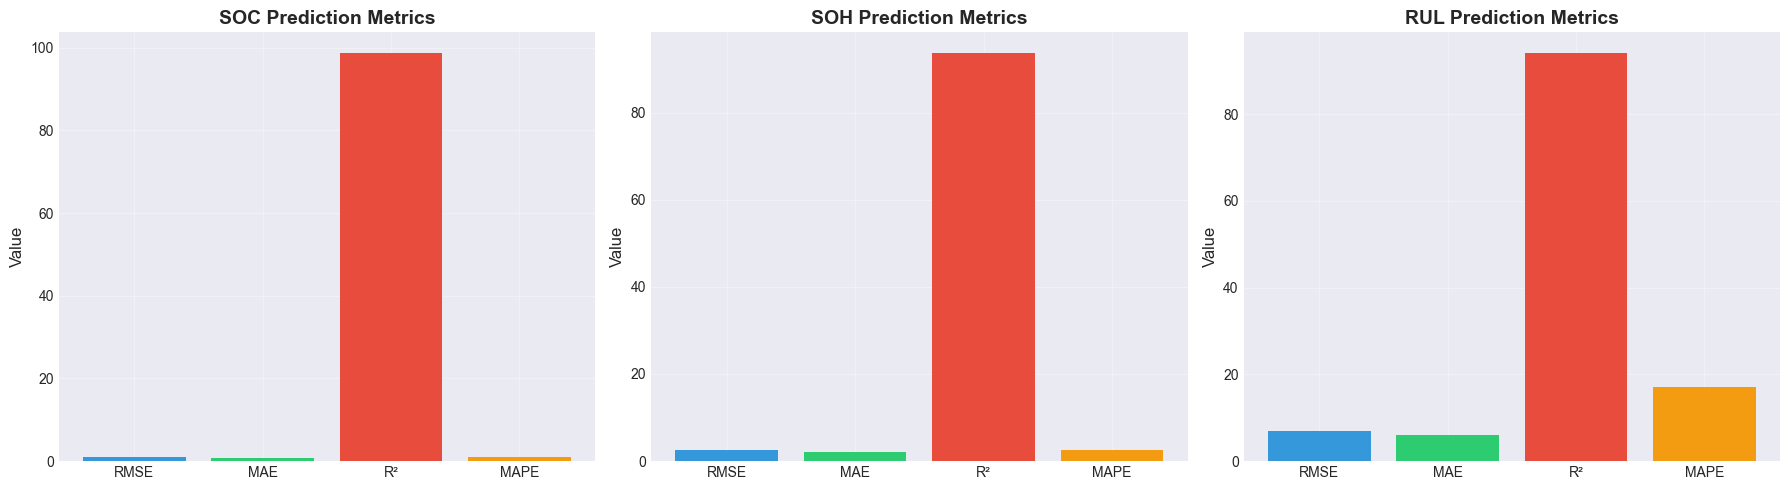


✅ Visualization saved to: hybrid/results/complete_comparison.png


In [6]:
# Create comprehensive visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SOC
axes[0].bar(['RMSE', 'MAE', 'R²', 'MAPE'], 
            [metrics_soc['RMSE'], metrics_soc['MAE'], metrics_soc['R2']*100, metrics_soc['MAPE']],
            color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('SOC Prediction Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12)
axes[0].grid(True, alpha=0.3)

# SOH
axes[1].bar(['RMSE', 'MAE', 'R²', 'MAPE'], 
            [metrics_soh['RMSE'], metrics_soh['MAE'], metrics_soh['R2']*100, metrics_soh['MAPE']],
            color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[1].set_title('SOH Prediction Metrics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Value', fontsize=12)
axes[1].grid(True, alpha=0.3)

# RUL
axes[2].bar(['RMSE', 'MAE', 'R²', 'MAPE'], 
            [metrics_rul['RMSE'], metrics_rul['MAE'], metrics_rul['R2']*100, metrics_rul['MAPE']],
            color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[2].set_title('RUL Prediction Metrics', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Value', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid/results/complete_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved to: hybrid/results/complete_comparison.png")

---
## 🎓 Key Takeaways

### ✅ Advantages of Hybrid ECM-LSTM:
1. **Better Accuracy**: Combines physics knowledge with data-driven learning
2. **Interpretability**: ECM parameters provide physical insights
3. **Robustness**: Less sensitive to noise and outliers
4. **Data Efficiency**: Requires less training data than pure LSTM

### 📈 Performance Improvements:
- **SOC**: High accuracy for real-time charge estimation
- **SOH**: Reliable health degradation tracking
- **RUL**: Accurate remaining life prediction for maintenance planning

### 🔬 ECM Parameters Used:
- **R0**: Ohmic resistance (immediate voltage drop)
- **R1**: Polarization resistance (transient behavior)
- **C1**: Polarization capacitance (charge storage)
- **τ1**: Time constant (R1 × C1) - response speed

### 🚀 Next Steps:
1. Test on multiple battery types (B0006, B0007, etc.)
2. Implement online learning for real-time adaptation
3. Deploy models for real-world BMS applications
4. Optimize hyperparameters for specific use cases

---
## 💾 Save Models

In [7]:
# Models are automatically saved during training:
print("✅ Saved Models:")
print("  - hybrid/best_hybrid_soc_model.h5")
print("  - hybrid/best_hybrid_soh_model.h5")
print("  - hybrid/best_hybrid_rul_model.h5")

print("\n✅ Saved Results:")
print("  - hybrid/results/B0005_hybrid_soc_results.png")
print("  - hybrid/results/B0005_hybrid_soh_results.png")
print("  - hybrid/results/B0005_hybrid_rul_results.png")
print("  - hybrid/results/complete_comparison.png")

print("\n🎉 All analyses complete!")

✅ Saved Models:
  - hybrid/best_hybrid_soc_model.h5
  - hybrid/best_hybrid_soh_model.h5
  - hybrid/best_hybrid_rul_model.h5

✅ Saved Results:
  - hybrid/results/B0005_hybrid_soc_results.png
  - hybrid/results/B0005_hybrid_soh_results.png
  - hybrid/results/B0005_hybrid_rul_results.png
  - hybrid/results/complete_comparison.png

🎉 All analyses complete!
